In [1]:
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt

# Path to the directory containing the datasets
DATA_DIR = 'datasets' 

# List and read in all CSV files in the directory
data_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
data_dfs = [pd.read_csv(DATA_DIR + '/' + f) for f in data_files]

# for n, df in enumerate(data_dfs):
#     if 'similarity' in df.columns:
#         data_dfs[n] = df[['datetime', 'ones']]
#         data_dfs[n]['bubbles'] = df.ones.cumsum()
#         del data_dfs[n]['ones']

# convert datetime columns to datetime object and set as index
for n, df in enumerate(data_dfs):
    df['datetime'] = [pd.to_datetime(dt) for dt in df['datetime']]
    df = df[df['datetime'].between('2019-01-01', '2020-03-01')]
    df = df.set_index('datetime', inplace=False)
    data_dfs[n] = df.copy()
    # data_dfs[n] = df[df['datetime'].between('2019-01-01', '2020-03-01')]
    # data_dfs[n] = df.set_index('datetime', inplace=False)

# pop : 4, 7, 13
# remove data that is irrelevant to the study
# del data_dfs[13]
# del data_dfs[7]
# del data_dfs[4]

data_dict = {}

for df in data_dfs:
    data_dict[df.columns[0]] = df.copy()


<Axes: xlabel='datetime'>

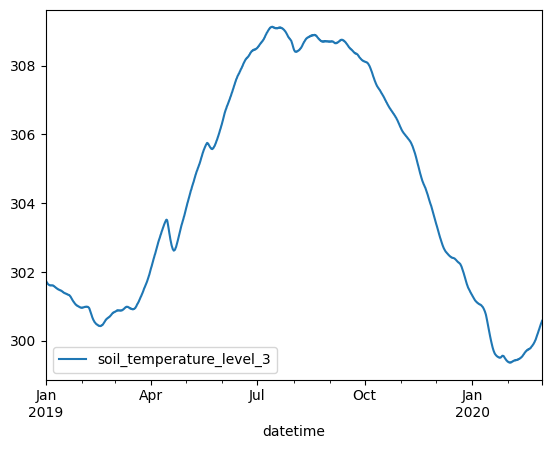

In [2]:
data_dict['soil_temperature_level_3'].plot()

In [3]:
for k in data_dict.keys():
    print(k)

soil_temperature_level_3
soil_temperature_level_2
bubble_count
soil_temperature_level_1
soil_temperature_level_4
total_precipitation_sum
temperature_c
total_precip
pressure_bar
surface_pressure
event_cnt
volumetric_soil_water_layer_2
volumetric_soil_water_layer_3
volumetric_soil_water_layer_1
volumetric_soil_water_layer_4
tide_nstr
temperature_2m


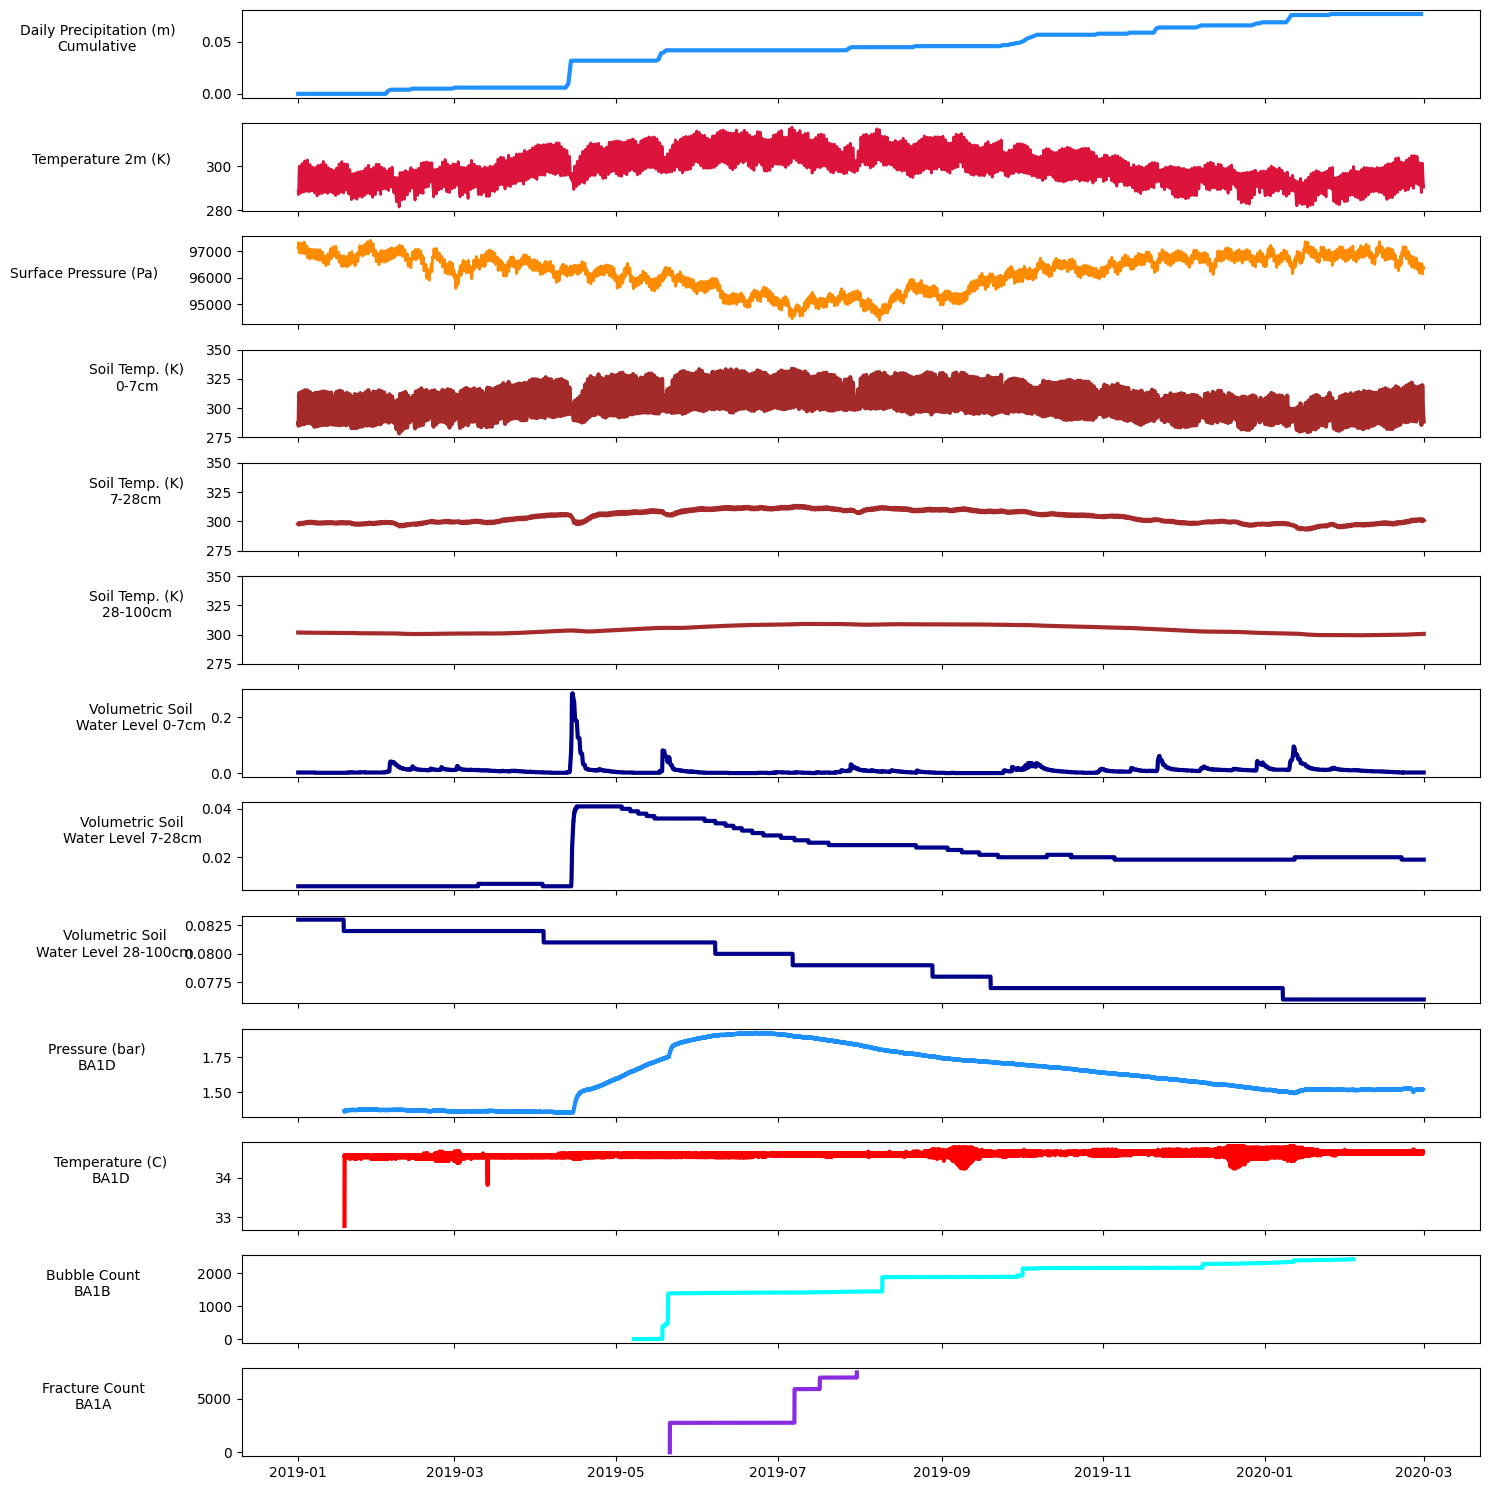

In [7]:
fig, axes = plt.subplots(len(data_dfs)-4, 1, sharex=True, figsize=(15, 15))

def plot_data(ax, data, cumulative=False, **kwargs):
    if cumulative==True:
        y = data_dict[data][data].values.cumsum()
    else:
        y = data_dict[data][data].values
    x = data_dict[data].index
    ax.plot(x, y, **kwargs)


# surface processes ERA5
plot_data(ax=axes[0], data='total_precipitation_sum', cumulative=True, color='dodgerblue', linewidth=3)
axes[0].set_ylabel('Daily Precipitation (m)\nCumulative', rotation=0, labelpad=75)

plot_data(ax=axes[1], data='temperature_2m', color='crimson', linewidth=2)
axes[1].set_ylabel('Temperature 2m (K)', rotation=0, labelpad=75)

plot_data(ax=axes[2], data='surface_pressure', color='darkorange', linewidth=2)
axes[2].set_ylabel('Surface Pressure (Pa)', rotation=0, labelpad=75)


# subsurface processes ERA5
plot_data(ax=axes[3], data='soil_temperature_level_1', color='brown', linewidth=3)
plot_data(ax=axes[4], data='soil_temperature_level_2', color='brown', linewidth=3)
plot_data(ax=axes[5], data='soil_temperature_level_3', color='brown', linewidth=3)

soil_labels = ['Soil Temp. (K)\n0-7cm', 'Soil Temp. (K)\n7-28cm', 'Soil Temp. (K)\n28-100cm']

for ax, lab in zip(axes[3:6], soil_labels):
    ax.set_ylabel(lab, rotation=0, labelpad=50)
    ax.set_ylim(275, 350)

plot_data(ax=axes[6], data='volumetric_soil_water_layer_1', color='darkblue', linewidth=3)
plot_data(ax=axes[7], data='volumetric_soil_water_layer_2', color='darkblue', linewidth=3)
plot_data(ax=axes[8], data='volumetric_soil_water_layer_3', color='darkblue', linewidth=3)

soil_labels = ['Volumetric Soil\nWater Level 0-7cm', 'Volumetric Soil\nWater Level 7-28cm', 'Volumetric Soil\nWater Level 28-100cm']

for ax, lab in zip(axes[6:9], soil_labels):
    ax.set_ylabel(lab, rotation=0, labelpad=50)

# borehole measurements
plot_data(axes[9], data='pressure_bar', color='dodgerblue', linewidth=3)
axes[9].set_ylabel('Pressure (bar)\nBA1D', rotation=0, labelpad=75)

plot_data(axes[10], data='temperature_c', color='red', linewidth=3)
axes[10].set_ylabel('Temperature (C)\nBA1D', rotation=0, labelpad=75)

plot_data(axes[11], data='bubble_count', color='aqua', linewidth=3)
axes[11].set_ylabel('Bubble Count\nBA1B', rotation=0, labelpad=75)

plot_data(axes[12], data='event_cnt', color='blueviolet', linewidth=3)
axes[12].set_ylabel('Fracture Count\nBA1A', rotation=0, labelpad=75)


fig.tight_layout()
        

NameError: name 'x' is not defined

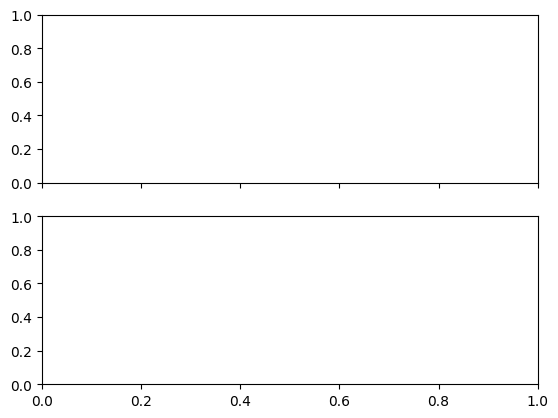

In [5]:
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(x, y)
ax[1].plot(data_dict['soil_temperature_level_1'].index, data_dict['soil_temperature_level_1']['soil_temperature_level_1'].values)

In [ ]:
data_dict['soil_temperature_level_1'].index